# Individual Structure (IS) aggregation

Given several subject DAG adjacency matrices, IS votes on edges and repairs
cycles so the result is a single global DAG (`aggregate_individual_structures`).

This notebook uses eight synthetic 4-node graphs. A majority threshold
(`tau = 0.5`) keeps edges that appear in more than half of the subjects; when
those votes would form a cycle, IS returns an acyclic consensus.

See also `04-is-vs-vts-multi-individual.ipynb` for IS versus VTS on retail data,
and `09-gs-clusters-then-vts-is.ipynb` for clustering subjects before aggregating.

In [2]:
import sys

sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np

from mdmp import aggregate_individual_structures, plot_dag

## Synthetic subject DAGs (4 nodes, 8 subjects)

Convention: `adj[i, j] == 1` means directed edge **parent i to child j** (same as MDM). Eight diverse acyclic graphs illustrate richer disagreement and possible cycles after thresholding.


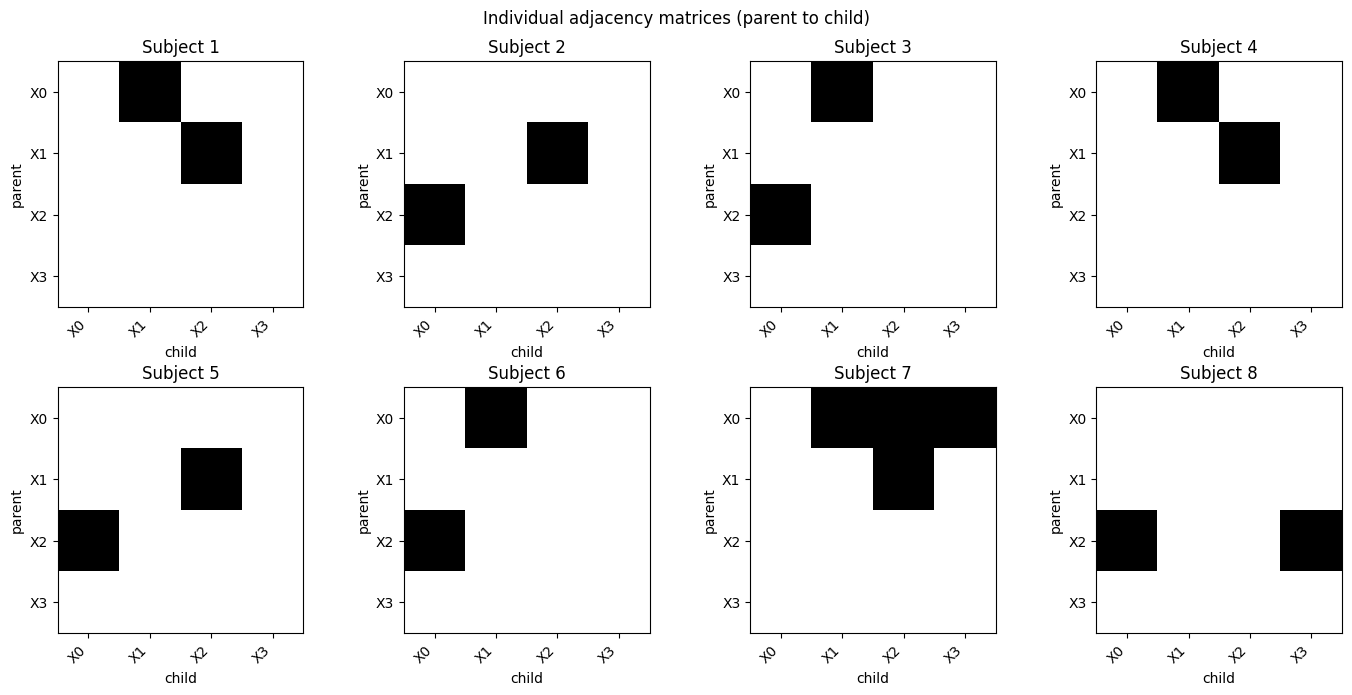

In [3]:
names = ["X0", "X1", "X2", "X3"]
n = 4

def dag():
    return np.zeros((n, n), dtype=int)

# Three rotations on {0,1,2} (each is a DAG); repeating patterns + extras ->
# majority voting can close a 3-cycle on X0,X1,X2 while X3 carries other edges.
g1 = dag()
g1[0, 1] = g1[1, 2] = 1
g2 = dag()
g2[1, 2] = g2[2, 0] = 1
g3 = dag()
g3[2, 0] = g3[0, 1] = 1
g4 = dag()
g4[0, 1] = g4[1, 2] = 1  # same as g1
g5 = dag()
g5[1, 2] = g5[2, 0] = 1  # same as g2
g6 = dag()
g6[2, 0] = g6[0, 1] = 1  # same as g3
g7 = dag()
g7[0, 1] = g7[0, 2] = g7[0, 3] = g7[1, 2] = 1  # star + 1->2 for extra 1->2 vote
g8 = dag()
g8[2, 0] = g8[2, 3] = 1  # extra vote for 2->0; 2->3 edge

subject_dags = [g1, g2, g3, g4, g5, g6, g7, g8]
S = len(subject_dags)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.ravel()
for ax, adj, s in zip(axes, subject_dags, range(1, S + 1)):
    ax.imshow(adj, cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=45, ha="right")
    ax.set_yticklabels(names)
    ax.set_xlabel("child")
    ax.set_ylabel("parent")
    ax.set_title(f"Subject {s}")
plt.suptitle("Individual adjacency matrices (parent to child)")
plt.tight_layout()
plt.show()


## Aggregation (`tau = 0.5`)

Default threshold: keep edges that appear in **more than half** of subjects (strict voting: frequency **>** τ).

The pooled graph may contain a **directed cycle**; repair is **greedy** (one cycle at a time: drop its lowest-frequency edge), not necessarily a global minimum feedback arc set.


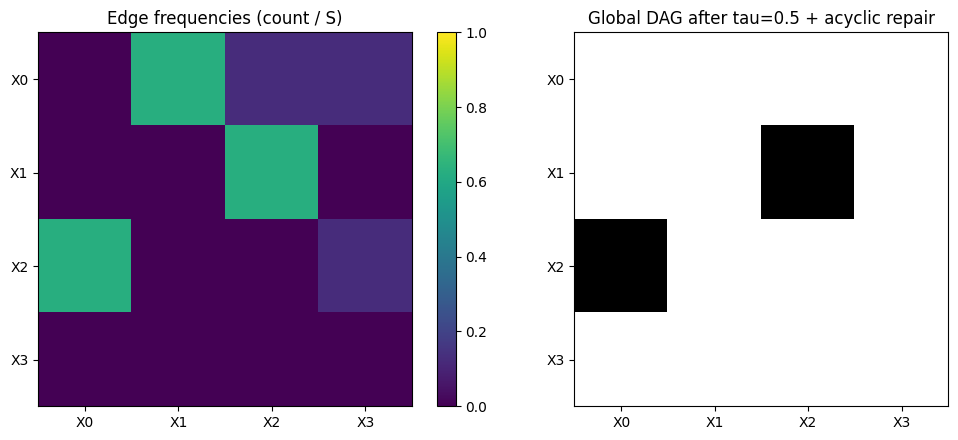

Edges removed for acyclicity:
{'parent_idx': 0, 'child_idx': 1, 'parent_name': 'X0', 'child_name': 'X1', 'frequency': 0.625}


In [4]:
tau = 0.5
result = aggregate_individual_structures(subject_dags, tau=tau, node_names=names)

freq = result.metadata["edge_frequencies"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
im0 = axes[0].imshow(freq, cmap="viridis", vmin=0, vmax=1)
axes[0].set_title("Edge frequencies (count / S)")
axes[0].set_xticks(range(n))
axes[0].set_yticks(range(n))
axes[0].set_xticklabels(names)
axes[0].set_yticklabels(names)
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(result.adj_mat, cmap="Greys", vmin=0, vmax=1)
axes[1].set_title(f"Global DAG after tau={tau} + acyclic repair")
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
axes[1].set_xticklabels(names)
axes[1].set_yticklabels(names)
plt.tight_layout()
plt.show()

print("Edges removed for acyclicity:")
for e in result.metadata["edges_removed_for_acyclicity"]:
    print(e)


## Global DAG (same interface as MDM for `plot_dag`)

`ISAggregatedMDMView` exposes `adj_mat` and `node_names` for `plot_dag`. Pass fitted **MDM** instances to `aggregate_individual_structures` to populate pooled `Filt` and `data` for `plot_arcs` (adjacency-only inputs return the consensus graph without filter fields).

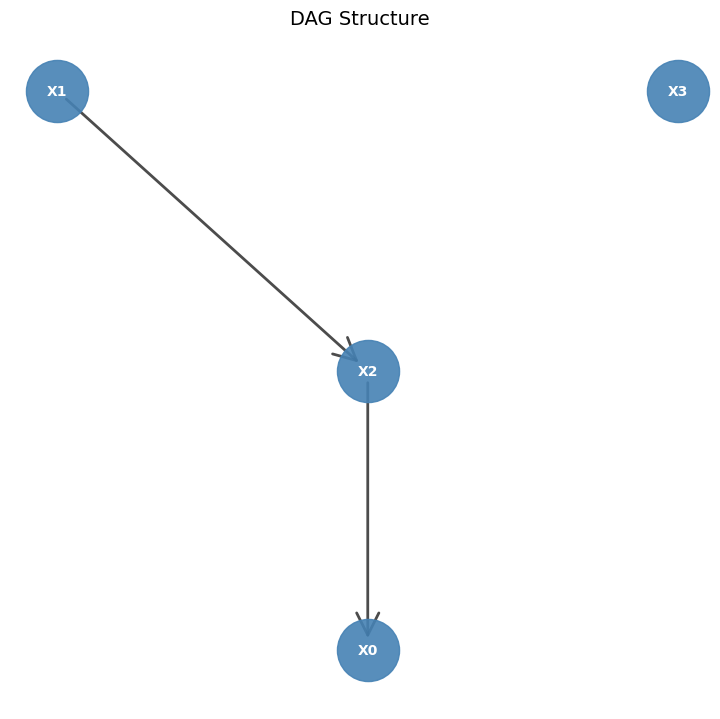

In [5]:
fig = plot_dag(result, plot_type="graph", layout_seed=0)
# fig

### Optional: `refit_mdm_on_structure` and Monte Carlo tuning

For Monte Carlo global edge coefficients, see `aggregate_individual_structures(..., mc_refit_global_structure=True, mc_posterior=..., mc_contributors=...)` and `mdmp.refit_mdm_on_structure` (same discount/filter/smooth pipeline as `MDM`, fixed DAG). `GlobalBetaMCResult` includes `beta_mean`, `beta_var`, and `beta_quantiles`.


In [6]:
# Inclusive τ example: 6/10 subjects share edge 0→1 at τ=0.6
edge01 = np.zeros((2, 2), dtype=int)
edge01[0, 1] = 1
no_edge = np.zeros((2, 2), dtype=int)
mats_10 = [edge01.copy() for _ in range(6)] + [no_edge.copy() for _ in range(4)]

from mdmp.group_analysis.inds.voting import vote_edge_frequencies

cand_strict, _, _ = vote_edge_frequencies(mats_10, 0.6, threshold_mode="strict")
cand_incl, _, _ = vote_edge_frequencies(mats_10, 0.6, threshold_mode="inclusive")
r_strict = aggregate_individual_structures(mats_10, tau=0.6, mc_n_samples=0)
print("strict (>0.6):", float(r_strict.adj_mat[0, 1]))
print("inclusive (≥0.6):", float(cand_incl[0, 1]))
print("frequency:", r_strict.metadata["edge_frequencies"][0, 1])


strict (>0.6): 0.0
inclusive (≥0.6): 1.0
frequency: 0.6
